In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os

In [3]:
def error_metric(j_e, j_d, weigh=1., coeff=1., dist_coeff=1., err_coeff=1., bias=1):
    cost = 1 / ((coeff * (j_e)) + 1e-15)
    cost = np.log(1 + cost)
    cost = np.clip((((cost + (dist_coeff * np.exp(j_d))) * np.power((1 - j_e), err_coeff)) - bias), 0, np.inf)
    return weigh * cost

In [4]:
def new_error_metric(j_e, j_d, weigh=1., coeff=1., dist_coeff=1.):
    cost = np.clip((np.exp(-j_e/coeff) * np.exp(j_d/dist_coeff)), 0, np.inf)
    return weigh * cost

In [5]:
it = 30

In [6]:
jump_distance = np.linspace(0.,1.,it)

In [7]:
# jump_error = np.linspace(0.001,0.2,it)[::-1]
jump_error = np.linspace(0.,1.,it)[::-1]

In [8]:
jump_error_grid, jump_distance_grid = np.meshgrid(jump_error, jump_distance)

In [9]:
# error_exp = error_metric(jump_error_grid, jump_distance_grid, 2, 1, 2, 1, 3)
# error_exp = error_metric(jump_error_grid, jump_distance_grid, 2, 5, 1, 10, 1)
# error_exp = error_metric(jump_error_grid, jump_distance_grid, 1, 0.5, 5, 4, 1)
# error_exp = error_metric(jump_error_grid, jump_distance_grid, 1, 2, 1.5, 0.8, 2)
# error_exp = error_metric(jump_error_grid, jump_distance_grid, 1, 0.1, 2, 1, 2)
# error_exp = error_metric(jump_error_grid, jump_distance_grid, 2, 0.5, 10, 1, 0)

# error_exp = new_error_metric(jump_error_grid, jump_distance_grid, 1, 1, 1, 1, 0)
error_exp = new_error_metric(jump_error_grid, jump_distance_grid, 1, 0.1, 1.5)

In [10]:
%matplotlib inline

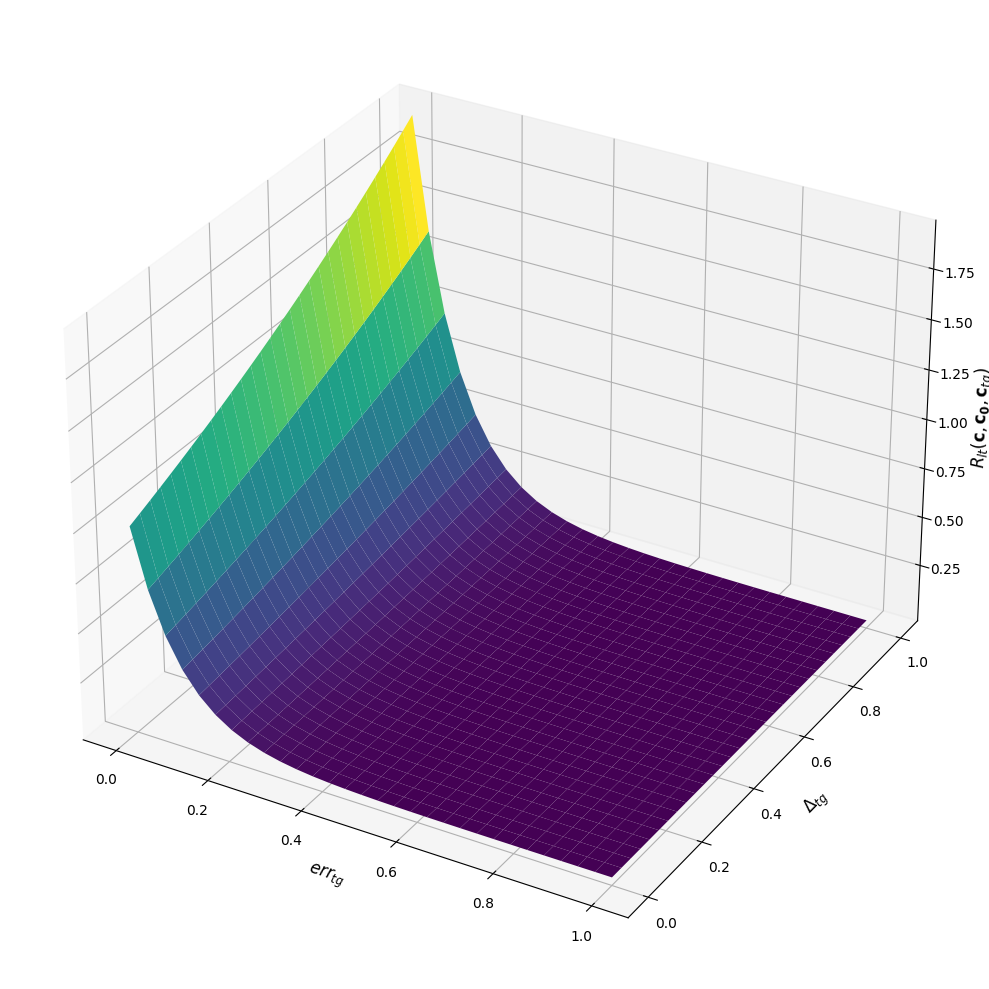

In [12]:
# Plot the 3D surface
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
# ax.plot_surface(jump_error_grid, jump_distance_grid, error_exp, cmap="viridis", rstride=1, cstride=1, edgecolor='none')
ax.plot_surface(jump_error_grid, jump_distance_grid, error_exp, cmap="viridis", rstride=1, cstride=1, edgecolor='none')
ax.set_xlabel("$err_{tg}$", fontsize=12)
ax.set_ylabel("$\Delta_{tg}$", fontsize=12)
ax.set_zlabel("$R_{lt}(\mathbf{c},\mathbf{c_{0}}, \mathbf{c}_{tg})$", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join("fig", "target_reward.pdf"), dpi=500)
plt.show()